In [1]:
print("Hello World")

Hello World


In [21]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

In [18]:
# STATE
class SimpleState(TypedDict):
  input_text: str
  output_text: str

# NODE 1
def process_input(state: SimpleState) -> SimpleState:
  op = state['input_text'].upper()
  return SimpleState(
    input_text=state['input_text'],
    output_text=op
  )

# NODE 2
def add_suffix(state: SimpleState) -> SimpleState:
  output_text = state['output_text']

  final = output_text + " SUFFIX"
  return SimpleState(
    input_text=state['input_text'],
    output_text=final
  )

# NODE 3
def add_prefix(state: SimpleState) -> SimpleState:
  output_text = state['output_text']

  final = "PREFIX " + output_text 
  return SimpleState(
    input_text=state['input_text'],
    output_text=final
  )


In [19]:
d = {
  "input_text": "hello",
  'output_text': ""
}

In [20]:
add_prefix(add_suffix(process_input(d)))

{'input_text': 'hello', 'output_text': 'PREFIX HELLO SUFFIX'}

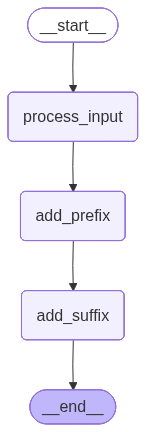

In [23]:
def create_simple_graph():
  builder = StateGraph(SimpleState)

  builder.add_node("process_input", process_input)
  builder.add_node("add_prefix", add_prefix)
  builder.add_node("add_suffix", add_suffix)

  builder.add_edge(START, "process_input")
  builder.add_edge("process_input", "add_prefix")
  builder.add_edge("add_prefix", "add_suffix")
  builder.add_edge("add_suffix", END)

  graph = builder.compile()
  return graph

create_simple_graph()

In [24]:
d = {
  "input_text": "hello",
  'output_text': ""
}

create_simple_graph().invoke(d)

{'input_text': 'hello', 'output_text': 'PREFIX HELLO SUFFIX'}